In [ ]:
# EDA - IEEE-CIS Fraud Detection
# Análisis Exploratorio de Datos y Limpieza Inicial para el TFM.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
# Para poder ver todas las columnas si son muchas
pd.set_option('display.max_columns', None) 

In [ ]:
# Rutas a los archivos
path_transaction = '../data/ieee/train_transaction.csv'
path_identity = '../data/ieee/train_identity.csv'

print("Cargando datasets...")
df_trans = pd.read_csv(path_transaction)
df_id = pd.read_csv(path_identity)

print(f"Forma original Transacciones: {df_trans.shape}")
print(f"Forma original Identidad: {df_id.shape}")

# Merge (left join)
df = df_trans.merge(df_id, on='TransactionID', how='left')

print(f"Forma tras el merge: {df.shape}")
print(f"Uso de memoria aproximado: {df.memory_usage().sum() / 1024**2:.2f} MB")

# Liberar memoria de los dataframes originales para no saturar la RAM
del df_trans, df_id

Cargando datasets...
Forma original Transacciones: (590540, 394)
Forma original Identidad: (144233, 41)
Forma tras el merge: (590540, 434)
Uso de memoria aproximado: 1955.37 MB


Porcentaje global de transacciones fraudulentas: 3.50%


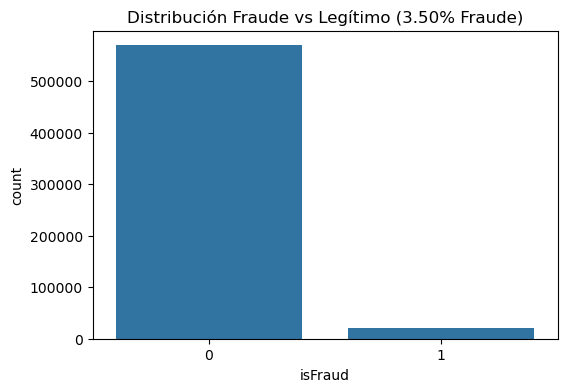

In [ ]:
# 1. Porcentaje promedio de fraude
fraude_pct = df['isFraud'].mean() * 100
print(f"Porcentaje global de transacciones fraudulentas: {fraude_pct:.2f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title(f"Distribución Fraude vs Legítimo ({fraude_pct:.2f}% Fraude)")
plt.show()


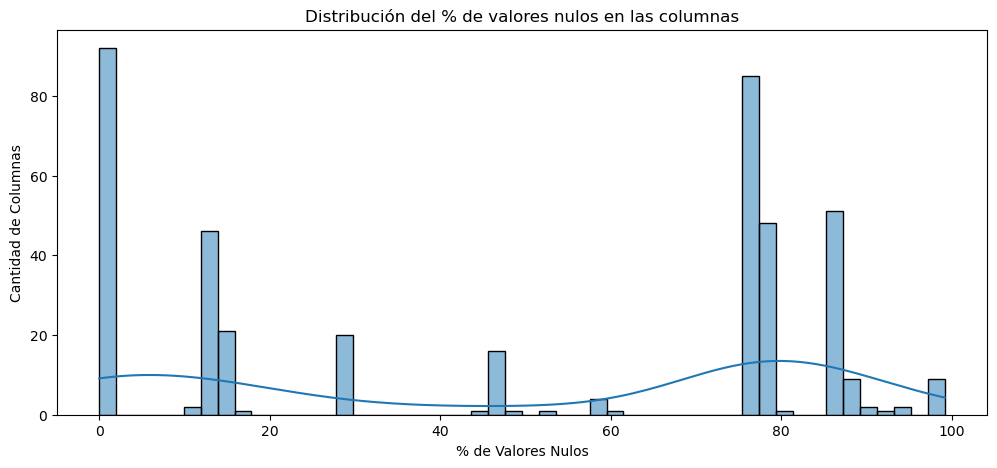

Total de columnas con más del 80% de nulos: 74


In [ ]:
# Calcular porcentaje de nulos por columna
missing_values = df.isnull().sum() / len(df) * 100
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.histplot(missing_values, bins=50, kde=True)
plt.title('Distribución del % de valores nulos en las columnas')
plt.xlabel('% de Valores Nulos')
plt.ylabel('Cantidad de Columnas')
plt.show()

print(f"Total de columnas con más del 80% de nulos: {(missing_values > 80).sum()}")

In [ ]:
def clean_data_experiment(dataframe):
    df_clean = dataframe.copy()
    
    # 1. Eliminar columnas con más de 80% de nulos
    umbral = 0.8
    cols_a_eliminar = df_clean.columns[df_clean.isnull().mean() > umbral]
    df_clean = df_clean.drop(columns=cols_a_eliminar)
    print(f"Se eliminaron {len(cols_a_eliminar)} columnas por tener > 80% de nulos.")
    
    # 2. Separar numéricas y categóricas para imputar el resto
    num_cols = df_clean.select_dtypes(include=['int16', 'int32', 'int64', 'float16', 'float32', 'float64']).columns
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    
    # Rellenar numéricas con la mediana
    for col in num_cols:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            
    # Rellenar categóricas con la moda
    for col in cat_cols:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
            
    return df_clean

# Probar la limpieza
df_cleaned = clean_data_experiment(df)
print(f"Forma del dataset limpio: {df_cleaned.shape}")
print(f"Nulos restantes: {df_cleaned.isnull().sum().sum()}")

Se eliminaron 74 columnas por tener > 80% de nulos.
Forma del dataset limpio: (590540, 360)
Nulos restantes: 0


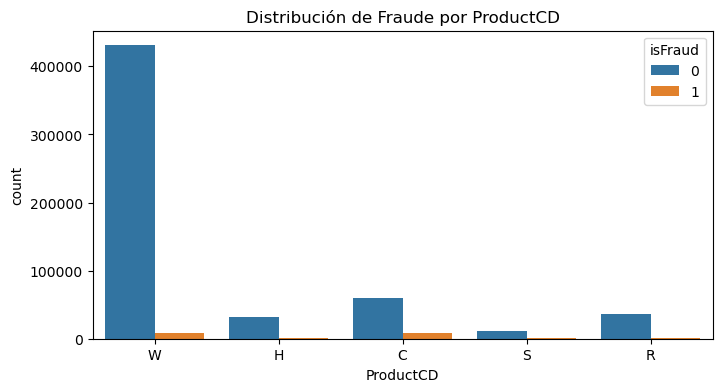

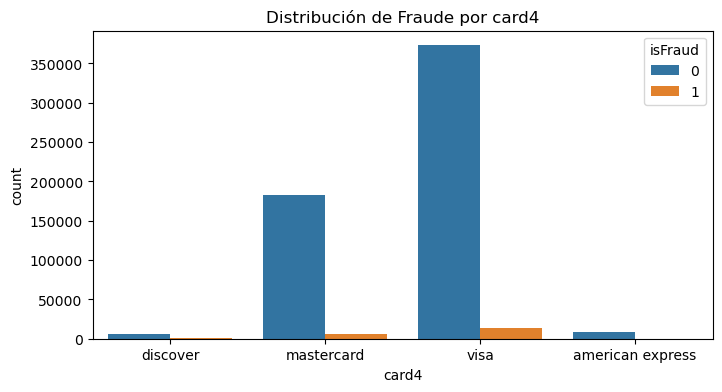

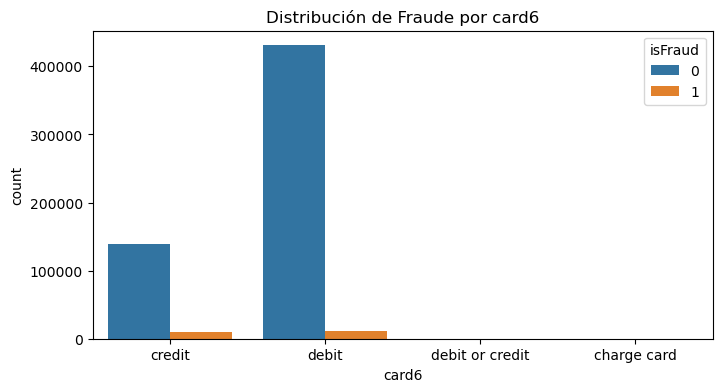

In [ ]:
# Analisis de variables categoricas vs Fraude
cat_cols_to_plot = ['ProductCD', 'card4', 'card6']

for col in cat_cols_to_plot:
    if col in df_cleaned.columns:
        plt.figure(figsize=(8, 4))
        sns.countplot(x=col, hue='isFraud', data=df_cleaned)
        plt.title(f'Distribución de Fraude por {col}')
        plt.show()

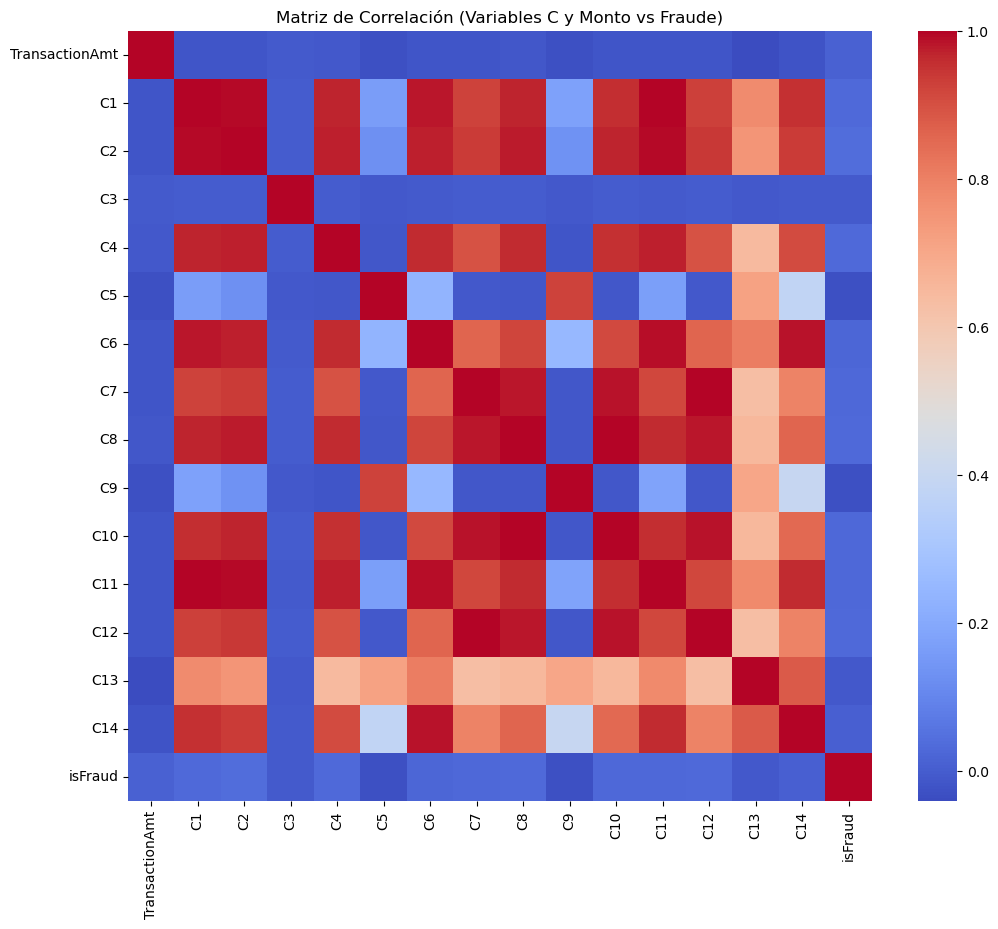

In [ ]:
# Matriz de correlación de las variables numéricas más importantes
# Usaremos TransactionAmt y las variables C (conteos) que suelen tener alta correlación
numeric_cols = ['TransactionAmt'] + [f'C{i}' for i in range(1, 15)]
numeric_cols = [c for c in numeric_cols if c in df_cleaned.columns] + ['isFraud']

plt.figure(figsize=(12, 10))
corr = df_cleaned[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación (Variables C y Monto vs Fraude)')
plt.show()

## Análisis Estadístico y Detección de Outliers
A continuación, realizaremos un resumen estadístico de las variables numéricas más relevantes y visualizaremos la distribución para identificar posibles valores atípicos (outliers).

In [ ]:
# Resumen estadístico básico de las variables analizadas
display(df_cleaned[numeric_cols].describe())

,TransactionAmt,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,isFraud
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,135.027176,14.092458,15.269734,0.005644,4.092185,5.571526,9.071082,2.848478,5.144574,4.480240,5.240343,10.241521,4.076227,32.539918,8.295215,0.034990
std,239.162522,133.569018,154.668899,0.150536,68.848459,25.786976,71.508467,61.727304,95.378574,16.674897,95.581443,94.336292,86.666218,129.364844,49.544262,0.183755
min,0.251000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,43.321000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
50%,68.769000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,1.000000,0.000000
75%,125.000000,3.000000,3.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,12.000000,2.000000,0.000000
max,31937.391000,4685.000000,5691.000000,26.000000,2253.000000,349.000000,2253.000000,2255.000000,3331.000000,210.000000,3257.000000,3188.000000,3188.000000,2918.000000,1429.000000,1.000000


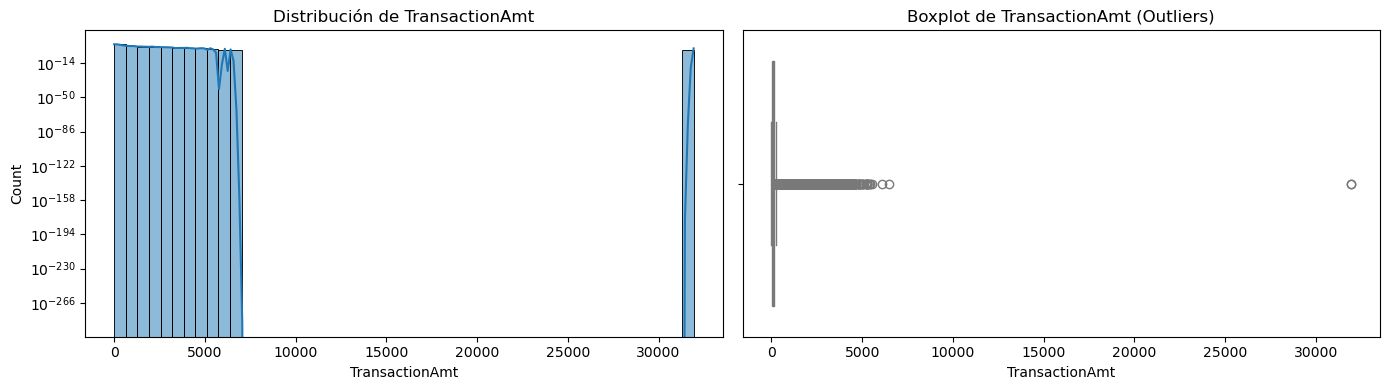

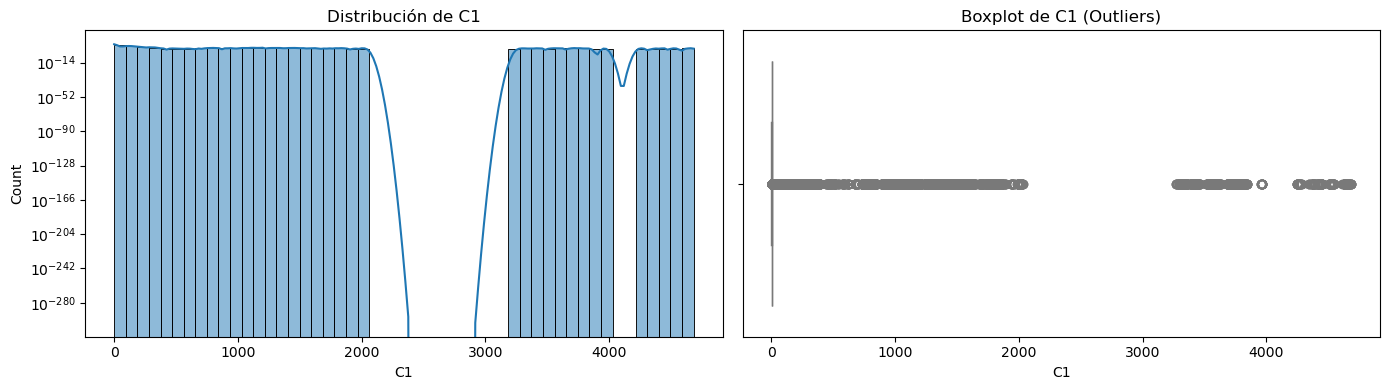

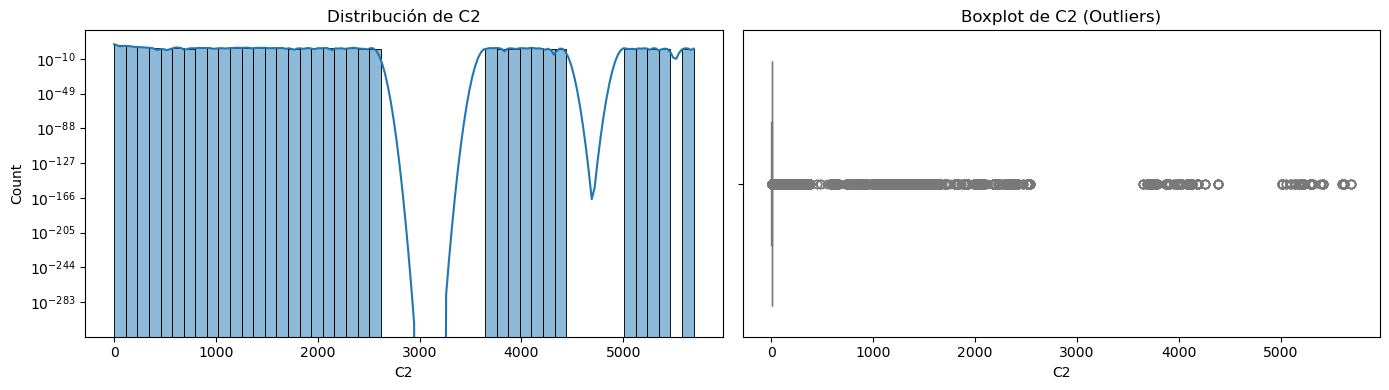

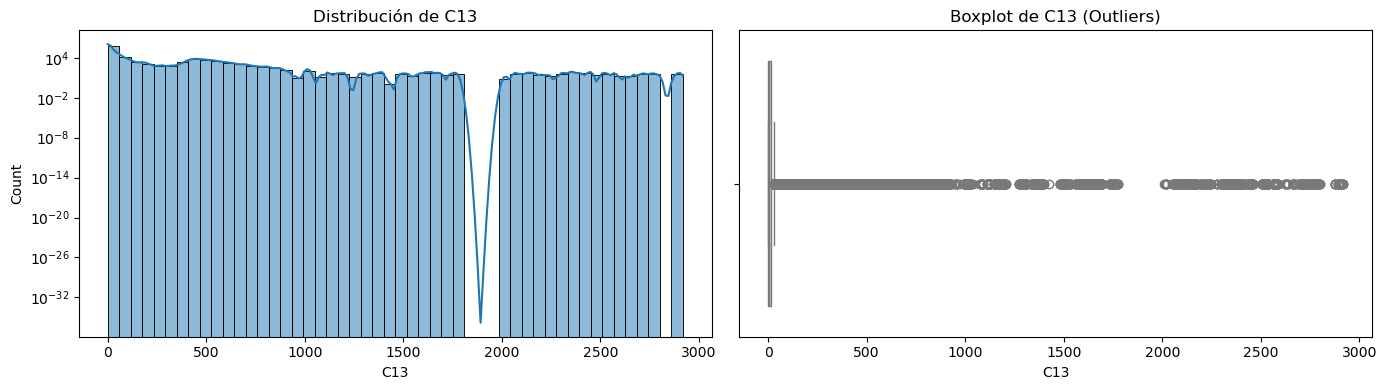

In [ ]:
# Histogramas y Boxplots (Gráficos de bigotes) para identificar outliers
vars_to_plot = ['TransactionAmt', 'C1', 'C2', 'C13']
vars_to_plot = [v for v in vars_to_plot if v in df_cleaned.columns]

for var in vars_to_plot:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    
    # Histograma
    sns.histplot(df_cleaned[var], bins=50, kde=True, ax=ax[0])
    ax[0].set_title(f'Distribución de {var}')
    ax[0].set_yscale('log') # Escala logarítmica debido a la asimetría y outliers
    
    # Boxplot
    sns.boxplot(x=df_cleaned[var], ax=ax[1], color='lightblue')
    ax[1].set_title(f'Boxplot de {var} (Outliers)')
    
    plt.tight_layout()
    plt.show()

## Guardado del Dataset Limpio
Exportamos el dataframe resultante a un nuevo archivo CSV para facilitar las etapas posteriores del proyecto y no tener que repetir la limpieza.

In [ ]:
# Guardar a CSV en la carpeta data
import os
os.makedirs('../data/ieee', exist_ok=True)

output_path = '../data/ieee/train_cleaned.csv'
print(f"Guardando el dataframe limpio en {output_path}...")
df_cleaned.to_csv(output_path, index=False)
print(f"¡Guardado exitoso! (Forma final: {df_cleaned.shape})")

Guardando el dataframe limpio en ../data/ieee/train_cleaned.csv...
¡Guardado exitoso! (Forma final: (590540, 360))


## Análisis de Comportamiento para Generación Sintética
A continuación analizaremos el comportamiento de los usuarios, el porcentaje de fraude y la distribución temporal (hora del día) para extraer parámetros clave.

Gasto promedio general por tarjeta: 149.57


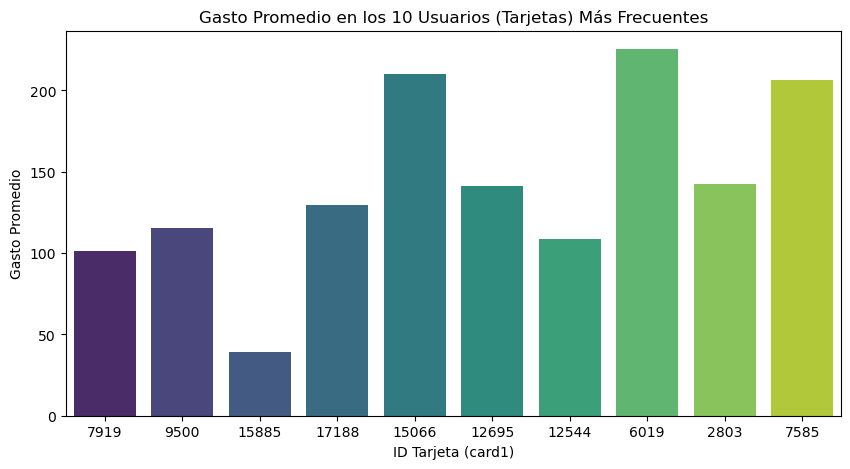

In [ ]:
# 2. Gasto promedio por usuario (usando card1 como proxy del usuario)
# Calculamos el gasto promedio y lo graficamos para los 10 "usuarios" con más transacciones
if "card1" in df_cleaned.columns:
    user_spending = df_cleaned.groupby("card1")["TransactionAmt"].mean().reset_index()
    print(f"Gasto promedio general por tarjeta: {user_spending['TransactionAmt'].mean():.2f}")
    
    # Top 10 tarjetas más frecuentes
    top_cards = df_cleaned["card1"].value_counts().head(10).index
    top_spending = user_spending[user_spending["card1"].isin(top_cards)]
    
    plt.figure(figsize=(10,5))
    sns.barplot(x="card1", y="TransactionAmt", data=top_spending, order=top_cards, palette="viridis")
    plt.title("Gasto Promedio en los 10 Usuarios (Tarjetas) Más Frecuentes")
    plt.xlabel("ID Tarjeta (card1)")
    plt.ylabel("Gasto Promedio")
    plt.show()

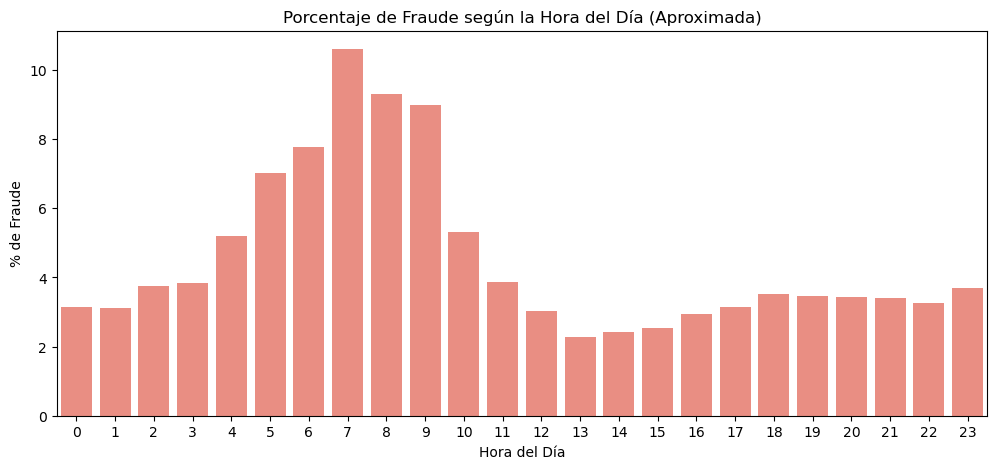

In [ ]:
# 3. ¿A qué hora ocurren más fraudes?
# TransactionDT es el tiempo en segundos desde una fecha de referencia.
# Podemos aproximar la hora del día haciendo modulo de 24 horas (86400 segundos)
if "TransactionDT" in df_cleaned.columns:
    df_cleaned["hour"] = (df_cleaned["TransactionDT"] // 3600) % 24
    
    plt.figure(figsize=(12, 5))
    # Porcentaje de fraude por hora
    fraud_by_hour = df_cleaned.groupby("hour")["isFraud"].mean() * 100
    sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values, color="salmon")
    plt.title("Porcentaje de Fraude según la Hora del Día (Aproximada)")
    plt.xlabel("Hora del Día")
    plt.ylabel("% de Fraude")
    plt.show()

## Análisis de Gastos apilados por fraude y análisis por día de la semana.

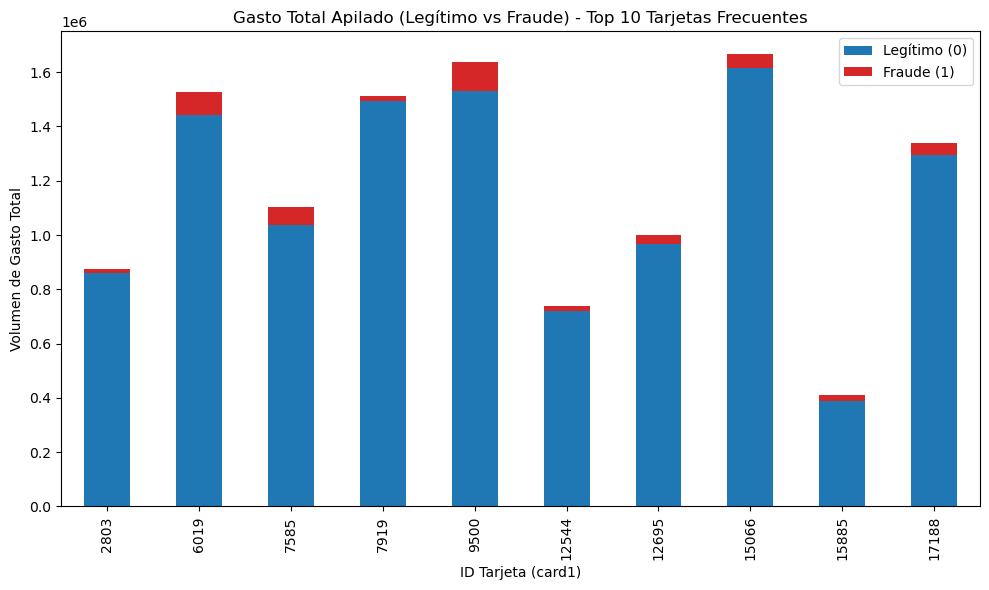

In [ ]:
# 4. Gasto Total apilado (Legítimo vs Fraude) para los 10 usuarios con más volumen de transacciones
# Nota: Usamos la suma total (volumen de gasto) en lugar de promedio porque apilar promedios 
# no tiene un significado matemático real (el promedio total no es la suma de los promedios).
if "card1" in df_cleaned.columns:
    top_cards_vol = df_cleaned["card1"].value_counts().head(10).index
    df_top = df_cleaned[df_cleaned["card1"].isin(top_cards_vol)]
    
    # Agrupar por tarjeta y si es fraude, sumando el monto
    spending_stacked = df_top.groupby(["card1", "isFraud"])["TransactionAmt"].sum().unstack(fill_value=0)
    
    spending_stacked.plot(kind="bar", stacked=True, figsize=(10,6), color=["#1f77b4", "#d62728"])
    plt.title("Gasto Total Apilado (Legítimo vs Fraude) - Top 10 Tarjetas Frecuentes")
    plt.xlabel("ID Tarjeta (card1)")
    plt.ylabel("Volumen de Gasto Total")
    plt.legend(["Legítimo (0)", "Fraude (1)"])
    plt.tight_layout()
    plt.show()

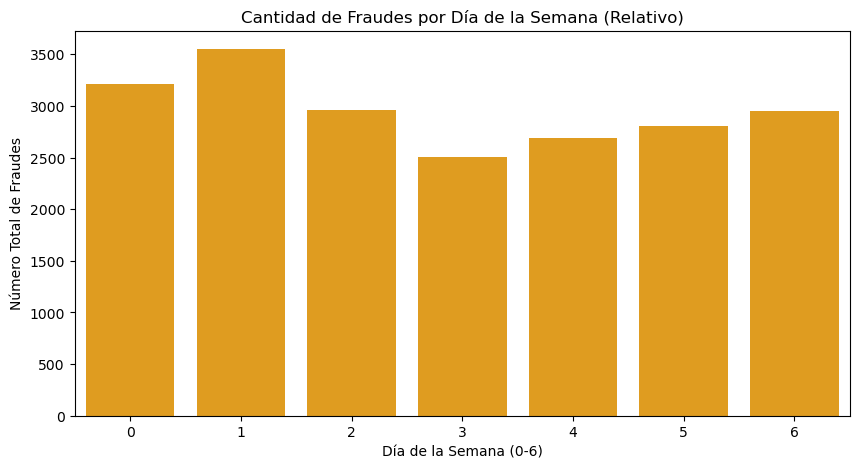

In [ ]:
# 5. ¿Qué día de la semana hay más fraude?
# TransactionDT está en segundos. Un día = 86400 segundos.
if "TransactionDT" in df_cleaned.columns:
    # Calculamos el día de la semana (0 a 6). 
    # El dataset original no especifica qué día es el 0, pero nos sirve para ver la distribución.
    df_cleaned["day_of_week"] = (df_cleaned["TransactionDT"] // 86400) % 7
    
    plt.figure(figsize=(10, 5))
    # Porcentaje o total de fraudes por día
    fraud_by_day = df_cleaned.groupby("day_of_week")["isFraud"].sum()
    sns.barplot(x=fraud_by_day.index, y=fraud_by_day.values, color="orange")
    plt.title("Cantidad de Fraudes por Día de la Semana (Relativo)")
    plt.xlabel("Día de la Semana (0-6)")
    plt.ylabel("Número Total de Fraudes")
    plt.show()